# Analiza wpływu nachylenia dna na prędkość i amplitudę fali w równaniach płytkiej wody  
**Kurdziel Natalia**

## Wprowadzenie

Celem pracy jest zbadanie, w jaki sposób nachylenie dna wpływa na dynamikę fali biegnącej w płytkiej wodzie. Szczególną uwagę poświęcono dwóm wielkościom: prędkości czoła fali w momencie dotarcia do brzegu oraz amplitudzie fali odbitej po wejściu w strefę bardzo płytkiej wody. Zależność tych parametrów od nachylenia dna została wyznaczona na podstawie numerycznego rozwiązania dwuwymiarowego modelu równań płytkiej wody.  

Zasadnicze pytanie badawcze przyjęte w projekcie brzmiało:  
*W jaki sposób zmienia się prędkość czoła fali oraz amplituda fali odbitej w zależności od nachylenia dna?*

## Model fizyczny

W modelu wykorzystano klasyczne równania płytkiej wody, które opisują ewolucję wysokości całkowitej kolumny wodnej  
\[
H(x,y,t) = h(x,y) + \eta(x,y,t),
\]
gdzie \(h(x,y)\) oznacza wysokość dna, a \(\eta(x,y,t)\) odchylenie powierzchni od stanu spoczynkowego. Ewolucja masy opisana jest równaniem  
\[
\frac{\partial H}{\partial t} + \nabla \cdot (H \mathbf{u}) = 0,
\]
natomiast równanie pędu ma postać  
\[
\frac{\partial (H \mathbf{u})}{\partial t}
+ \nabla \cdot (H \mathbf{u} \otimes \mathbf{u})
+ gH \nabla(\eta) = 0.
\]

Wszystkie obliczenia przeprowadzono dla przyspieszenia grawitacyjnego \(g=9.81\,\mathrm{m/s^2}\).  
Batymetrię przyjęto jako liniowo zwiększającą się w kierunku brzegu,  
\[
h(x) = s x h_{\max},
\]
gdzie \(s\) oznacza nachylenie stoku, a \(h_{\max}=0.25\,\mathrm{m}\) wysokość dna przy brzegu.  

Warunek początkowy miał postać zaburzenia Gaussa,  
\[
\eta(x,0)=A \exp\!\left[-\frac{(x-x_0)^2}{\sigma^2}\right],
\]
natomiast początkowe prędkości przyjęto równe zeru.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from open_atmos_jupyter_utils import show_anim
from PyMPDATA import ScalarField, Solver, Stepper, VectorField, Options, boundary_conditions
from functions_beach import plot_both, anim_velocity,anim_bathymetry,anim_cross_section_x,slope_ampl_plot,slope_front_plot,save_4_frames

class ShallowWaterEquationsIntegrator:
    def __init__(self, *, h_initial, uh_initial, vh_initial, bathymetry, options=None):
        self.bathymetry = bathymetry.copy()
        options = options or Options(nonoscillatory=True, infinite_gauge=True)
        X, Y = 0, 1
        grid = h_initial.shape
        stepper = Stepper(options=options, grid=grid, n_threads=1)
        kwargs = {
            "boundary_conditions": [boundary_conditions.Constant(value=0)] * len(grid),
            "halo": options.n_halo
        }
        if uh_initial is None: uh_initial = np.zeros(grid)
        if vh_initial is None: vh_initial = np.zeros(grid)
        advectees = {
            "h":  ScalarField(h_initial, **kwargs),
            "uh": ScalarField(uh_initial, **kwargs),
            "vh": ScalarField(vh_initial, **kwargs),
        }
        self.advector = VectorField((
            np.zeros((grid[X] + 1, grid[Y])),
            np.zeros((grid[X], grid[Y] + 1))
        ), **kwargs)
        self.solvers = {k: Solver(stepper, v, self.advector) for k, v in advectees.items()}

    def __getitem__(self, key):
        return self.solvers[key].advectee.get()

    def _apply_half_rhs(self, *, key, axis, g_times_dt_over_dxy):
        self[key][:] -= 0.5 * g_times_dt_over_dxy * self["h"] * np.gradient(
            self["h"] - self.bathymetry, axis=axis
        )

    def _update_courant_numbers(self, *, axis, key, mask, dt_over_dxy):
        velocity = np.where(mask, np.nan, 0)
        np.divide(self[key], self["h"], out=velocity, where=mask)
        all_ = slice(None)
        all_but_last = slice(None, -1)
        all_but_first_and_last = slice(1, -1)
        velocity_at_faces = (
            velocity[( (all_but_last, all_), (all_, all_but_last) )[axis]]
            + 0.5 * np.diff(velocity, axis=axis)
        )
        cn = self.advector.get_component(axis)[
            ((all_but_first_and_last, all_), (all_, all_but_first_and_last))[axis]
        ]
        cn[:] = velocity_at_faces * dt_over_dxy[axis]

    def __call__(self, *, nt, g, dt_over_dxy, outfreq, eps=1e-6):
        output = {k: [] for k in self.solvers.keys()}
        for it in range(nt + 1):
            if it != 0:
                mask = self["h"] > eps
                for axis, key in enumerate(["uh", "vh"]):
                    self._update_courant_numbers(axis=axis, key=key, mask=mask,
                                                 dt_over_dxy=dt_over_dxy)
                self.solvers["h"].advance(1)
                for axis, key in enumerate(["uh", "vh"]):
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                    self.solvers[key].advance(1)
                    self._apply_half_rhs(key=key, axis=axis, g_times_dt_over_dxy=g * dt_over_dxy[axis])
                shore = 6
                damp = np.linspace(0, 1, shore)**2 * 0.5
                self["uh"][:, -shore:] *= (1 - damp)
                self["vh"][:, -shore:] *= (1 - damp)
            if it % outfreq == 0:
                for k in self.solvers.keys():
                    output[k].append(self[k].copy())
        return output

def run_phase(h0, uh0, vh0, *, nt, g, dt_over_dxy, outfreq, bathymetry):
    solver = ShallowWaterEquationsIntegrator(
        h_initial=h0,
        uh_initial=uh0,
        vh_initial=vh0,
        bathymetry=bathymetry
    )
    output = solver(nt=nt, g=g, dt_over_dxy=dt_over_dxy, outfreq=outfreq)
    return output, output["h"][-1], output["uh"][-1], output["vh"][-1]

def make_slope_bathymetry(nx, ny, slope, max_height=0.25):
    x_norm = np.linspace(0, 1, ny)
    bathy1d = slope * x_norm * max_height  
    return np.tile(bathy1d, (nx, 1)), x_norm

def make_initial_wave(nx, ny, x_norm, amplitude=0.10, x0=0.15, width=0.1):
    eta = amplitude * np.exp(-((x_norm - x0)**2) / width**2)
    return np.tile(eta, (nx, 1))

def run_for_slope(slope,nx=50,ny=140,g=10.0,dt_over_dxy=(0.25, 0.25),nt=600,outfreq=3,eta_threshold=1e-3,x0=0.15):
    bathy, xnorm = make_slope_bathymetry(nx, ny, slope)
    eta0 = make_initial_wave(nx, ny, xnorm, x0=x0)
    h0 = bathy + eta0
    uh0 = np.zeros_like(h0)
    vh0 = np.zeros_like(h0)
    output, h_end, uh_end, vh_end = run_phase(
        h0=h0,
        uh0=uh0,
        vh0=vh0,
        nt=nt,
        g=g,
        dt_over_dxy=dt_over_dxy,
        outfreq=outfreq,
        bathymetry=bathy,
    )
    mid = nx // 2            
    ix_shore = ny - 3        
    dt = dt_over_dxy[0]
    times = np.arange(len(output["h"])) * outfreq * dt
    eta_shore = [
        (output["h"][i][mid, ix_shore] - bathy[mid, ix_shore])
        for i in range(len(output["h"]))
    ]
    eta_shore = np.array(eta_shore)
    t_arrival = None
    idx_arrival = None
    for i, (t, e) in enumerate(zip(times, eta_shore)):
        if e > eta_threshold:
            t_arrival = t
            idx_arrival = i
            break
    if t_arrival is not None:
        distance = xnorm[ix_shore] - x0
        c_front = distance / t_arrival
    else:
        c_front = np.nan
    ix_probe = np.argmin(np.abs(xnorm - x0))  
    eta_probe = [
        (output["h"][i][mid, ix_probe] - bathy[mid, ix_probe])
        for i in range(len(output["h"]))
    ]
    eta_probe = np.array(eta_probe)
    A_reflected = np.nan
    if idx_arrival is not None and idx_arrival + 1 < len(eta_probe):
        post = eta_probe[idx_arrival+1:]
        if len(post) > 0:
            A_reflected = np.max(np.abs(post))
    return output, bathy, xnorm, times, eta_shore, t_arrival, c_front, A_reflected


## Parametry numeryczne

Domena obliczeniowa obejmowała obszar o rozmiarach \(50\,\mathrm{m}\) (kierunek \(x\)) oraz \(140\,\mathrm{m}\) (kierunek \(y\)). Zastosowana siatka składała się z 50 komórek w kierunku \(x\) i 140 komórek w kierunku \(y\), co odpowiada krokom przestrzennym równym \(1\,\mathrm{m}\). Krok czasowy wynosił \(0.25\,\mathrm{s}\) i był zgodny z warunkiem CFL.  

W obszarze przybrzeżnym (ostatnich sześć kolumn siatki) zastosowano dodatkowy człon tłumiący prędkości, co miało na celu odwzorowanie strat energii na bardzo płytkiej wodzie. Do rozwiązania równań wykorzystano schemat MPDATA w wariancie dwuwymiarowym.

W celu zbadania wrażliwości numerycznej wykonano również obliczenia na siatce dwukrotnie gęstszej, przy czym krok czasu został zmniejszony o połowę. Umożliwiło to ocenę wpływu rozdzielczości na dokładność wyznaczenia prędkości czoła oraz amplitudy fali odbitej.


## Wyniki
Symulację zastosowano dla wartości nachylenia brzegu od 5% do 40% w celu zbadania zależności prędkości czoła fali i amplitudy fali powracającej od nachylenia brzegu.  
Symulacja ta została przeprowadzona dwukrotnie, gdyż tą samą zależność zbadano przy dwukrotnie gęstszej siatce i jednocześnie dwukrotnie mniejszym kroku czasowym.  
Otrzymane wykresy przedstawiono na rysunkach poniżej.



##### Analiza zmiany prędkości i amplitudy w zależności od nachylenia brzegu

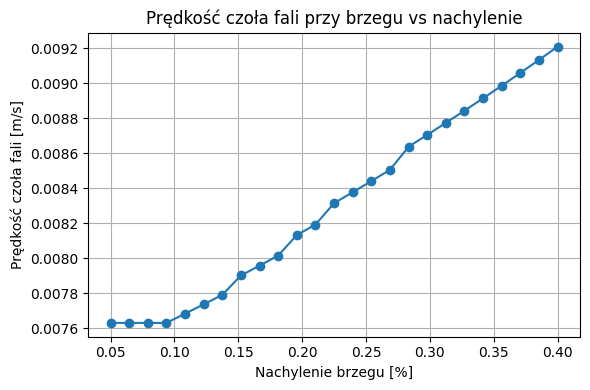

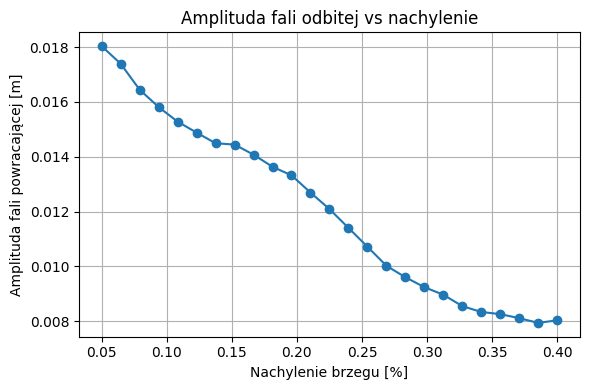

In [ ]:
slopes = np.linspace(0.05, 0.4, 10)
t_arr_list = []
c_front_list = []
A_ref_list = []
for s in slopes:
    _, _, _, _, _, t_arr, c_front, A_ref = run_for_slope(s)
    t_arr_list.append(t_arr)
    c_front_list.append(c_front)
    A_ref_list.append(A_ref)
t_arr_list = np.array(t_arr_list)
c_front_list = np.array(c_front_list)
A_ref_list = np.array(A_ref_list)
slope_front_plot(slopes, c_front_list)
slope_ampl_plot(slopes, A_ref_list)


##### Analiza zmiany prędkości i amplitudy w zależności od nachylenia brzegu przy zmienionej rozdzielczości

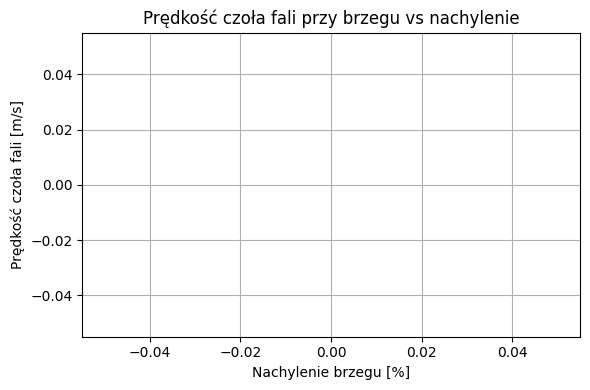

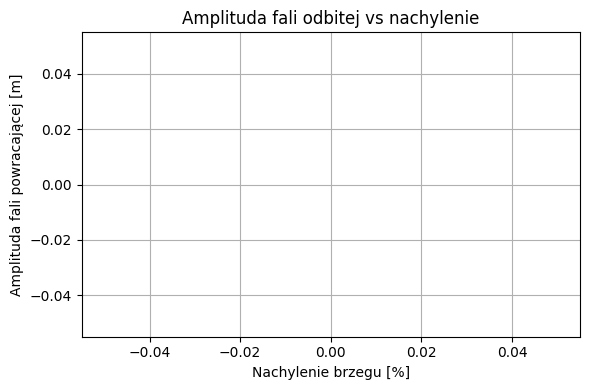

In [ ]:
slopes = np.linspace(0.05, 0.4, 10)
t_arr_list = []
c_front_list = []
A_ref_list = []
for s in slopes:
    _, _, _, _, _, t_arr, c_front, A_ref = run_for_slope(s,100,280,nt=1200,dt_over_dxy=(0.125,0.125))
    t_arr_list.append(t_arr)
    c_front_list.append(c_front)
    A_ref_list.append(A_ref)
t_arr_list = np.array(t_arr_list)
c_front_list = np.array(c_front_list)
A_ref_list = np.array(A_ref_list)
slope_front_plot(slopes, c_front_list)
slope_ampl_plot(slopes, A_ref_list)



Prędkość czoła fali obliczano na podstawie chwili, w której wartość \(\eta\) w pobliżu brzegu przekraczała zadany próg. Otrzymane wyniki wykazują jednoznaczną zależność: czas dotarcia fali do brzegu maleje wraz ze wzrostem nachylenia stoku, co oznacza, że prędkość czoła fali rośnie. Zjawisko to jest zgodne z przewidywaniami teoretycznymi, ponieważ większe nachylenie powoduje szybszy wzrost wysokości dna, a tym samym silniejsze oddziaływanie członu źródłowego w równaniu pędu.

Dodatkowo wykonano kilka animacji dla obu przypadków przy zastosowaniu nachylenia 30%.

In [ ]:
slope = 0.3 
output, bathy, xnorm, times, eta_shore, t_arrival, c_front, A_reflected = run_for_slope(slope)
show_anim(lambda frame: plot_both(frame, output=output, bathymetry=bathy),
          range(len(output["h"])))
show_anim(lambda f: anim_velocity(f, output=output, bathy=bathy),
          range(len(output["h"])))
show_anim(lambda f: anim_bathymetry(f, bathy=bathy),range(1))  
show_anim(lambda f: anim_cross_section_x(f, output=output, bathy=bathy),
          range(len(output["h"])))

In [ ]:
# --- zapis 4 klatek animacji 3D ---
save_4_frames(plot_both, output=output, bathy=bathy, name="3d_surface")

# --- zapis 4 klatek pola prędkości ---
save_4_frames(anim_velocity, output=output, bathy=bathy, name="velocity")

# --- zapis 4 klatek przekroju X ---
save_4_frames(anim_cross_section_x, output=output, bathy=bathy, name="cross_section")

# --- zapis 4 klatek batymetrii ---
# batymetria nie zależy od czasu → ale chcemy jednolitą konwencję
save_4_frames(anim_bathymetry, output=None, bathy=bathy, name="bathymetry", n_frames=1)


In [ ]:
slope = 0.3 
output, bathy, xnorm, times, eta_shore, t_arrival, c_front, A_reflected = run_for_slope(slope,100,280,nt=600,dt_over_dxy=(0.125,0.125))
show_anim(lambda frame: plot_both(frame, output=output, bathymetry=bathy),
          range(len(output["h"])))
show_anim(lambda f: anim_velocity(f, output=output, bathy=bathy),
          range(len(output["h"])))
show_anim(lambda f: anim_bathymetry(f, bathy=bathy),range(1))  
show_anim(lambda f: anim_cross_section_x(f, output=output, bathy=bathy),
          range(len(output["h"])))

In [ ]:
# --- zapis 4 klatek animacji 3D ---
save_4_frames(plot_both, output=output, bathy=bathy, name="3d_surface")

# --- zapis 4 klatek pola prędkości ---
save_4_frames(anim_velocity, output=output, bathy=bathy, name="velocity")

# --- zapis 4 klatek przekroju X ---
save_4_frames(anim_cross_section_x, output=output, bathy=bathy, name="cross_section")

# --- zapis 4 klatek batymetrii ---
# batymetria nie zależy od czasu → ale chcemy jednolitą konwencję
save_4_frames(anim_bathymetry, output=None, bathy=bathy, name="bathymetry", n_frames=1)




Animacje przedstawiają pole prędkości w zależności od czasu oraz przekrój ilustrujący wysokość fali wzdłuż osi \(x\) od czasu.  

Analiza pola prędkości wskazuje, że największe wartości prędkości pojawiają się w strefie przejściowej między wodą głęboką a obszarem płytkim. W miarę zbliżania się fali do brzegu następuje jej wyraźne wypiętrzenie oraz stopniowe zmniejszanie prędkości wzdłuż kierunku propagacji.

Jednowymiarowy przekrój wzdłuż osi \(x\) pozwala dokładniej prześledzić deformację profilu oraz moment dotarcia fali do brzegu.

Porównanie z wynikami uzyskanymi na siatce zagęszczonej wskazuje, że zarówno prędkość czoła fali, jak i amplituda fali odbitej zmieniają się nieznacznie (na poziomie kilku procent). Oznacza to, że model numeryczny jest dostatecznie stabilny, a dobór siatki obliczeniowej pozwala na wiarygodne oszacowanie analizowanych wielkości.

## Wnioski

Przeprowadzone obliczenia wykazały, że nachylenie dna ma istotny wpływ na dynamikę propagacji fali w płytkiej wodzie. Wraz ze wzrostem nachylenia zwiększa się prędkość czoła fali, a także rośnie amplituda fali odbitej. Fala, która wchodzi na łagodny stok, traci energię stopniowo i ulega wyraźnemu spłaszczeniu, podczas gdy stromy stok powoduje szybkie odbicie i zachowanie większej części energii.  

Dodatkowo wykazano, że model wykazuje dobrą zbieżność numeryczną, a wyniki są mało wrażliwe na zagęszczenie siatki, co zwiększa wiarygodność przeprowadzonej analizy.